# RQ1: Individual Influential Factors in Trend Classification

**Research question:** What factors, such as platform, region, content category, traffic source, and engagement metrics, most strongly influence video trend classification?


## 1. Load Processed Data

The preprocessing notebook already cleaned missing values, encoded categorical variables, and saved numeric train/validation/test files.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score

train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")
feature_metadata = pd.read_csv("../data/processed/feature_metadata.csv")

TARGET = "trend_label"

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

display(y_train.value_counts(normalize=True).sort_index())
display(feature_metadata.head())

Train: (33655, 203) (33655,)
Validation: (7212, 203) (7212,)
Test: (7212, 203) (7212,)


trend_label
declining    0.249651
rising       0.251701
seasonal     0.252622
stable       0.246026
Name: proportion, dtype: float64

,feature,original_feature,feature_group
0,week_of_year,week_of_year,temporal
1,duration_sec,duration_sec,content_basic
2,views,views,engagement_observed
3,likes,likes,engagement_observed
4,comments,comments,engagement_observed


## 2. Feature Inventory


In [3]:
feature_inventory = pd.DataFrame([
    {
        "feature": column,
        "dtype": str(X_train[column].dtype),
        "missing_rate": X_train[column].isna().mean(),
        "n_unique": X_train[column].nunique(dropna=True),
    }
    for column in X_train.columns
]).sort_values("n_unique", ascending=True)

print("Number of model features:", len(feature_inventory))
display(feature_inventory.head(50))

Number of model features: 203


,feature,dtype,missing_rate,n_unique
101,category_science,int64,0.0,2
129,hashtag_#makeup,int64,0.0,2
130,hashtag_#morningroutine,int64,0.0,2
131,hashtag_#motivation,int64,0.0,2
132,hashtag_#music,int64,0.0,2
133,hashtag_#ootd,int64,0.0,2
134,hashtag_#pets,int64,0.0,2
135,hashtag_#recipe,int64,0.0,2
136,hashtag_#relatable,int64,0.0,2
137,hashtag_#skincare,int64,0.0,2


## 3. Baseline and Random Forest Model

This section compares a majority-class baseline against a Random Forest classifier. The baseline is included to check whether the model is learning more than the class distribution alone.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

tuning_rows = []

for n_estimators in [50, 100, 200]:
    for min_samples_leaf in [1, 5, 10]:
        rf_temp = RandomForestClassifier(
            n_estimators=n_estimators,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42
        )
        rf_temp.fit(X_train, y_train)
        y_pred = rf_temp.predict(X_val)

        tuning_rows.append({
            "n_estimators": n_estimators,
            "min_samples_leaf": min_samples_leaf,
            "val_accuracy": accuracy_score(y_val, y_pred),
            "val_macro_f1": f1_score(y_val, y_pred, average="macro")
        })

rf_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    "val_macro_f1",
    ascending=False
).reset_index(drop=True)

display(rf_tuning_results.round(4))

# Select best hyperparameters based on validation macro-F1
best_params = rf_tuning_results.iloc[0]

rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)

rf.fit(X_train, y_train)

# Evaluate baseline and tuned random forest
rows = []

for model_name, model in [
    ("majority_baseline", baseline),
    ("random_forest_tuned", rf),
]:
    for split_name, X_part, y_part in [
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        y_pred = model.predict(X_part)

        rows.append({
            "model": model_name,
            "split": split_name,
            "accuracy": accuracy_score(y_part, y_pred),
            "macro_f1": f1_score(y_part, y_pred, average="macro"),
        })

model_scores = pd.DataFrame(rows)

model_scores["split"] = pd.Categorical(
    model_scores["split"],
    categories=["validation", "test"],
    ordered=True,
)

model_scores = model_scores.sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
).reset_index(drop=True)

display(model_scores.round(4))

,n_estimators,min_samples_leaf,val_accuracy,val_macro_f1
0,50,5,0.2622,0.2621
1,100,5,0.2601,0.2600
2,200,5,0.2547,0.2545
3,200,1,0.2522,0.2516
4,50,10,0.2511,0.2510
5,50,1,0.2493,0.2479
6,100,10,0.2456,0.2455
7,200,10,0.2436,0.2436
8,100,1,0.2415,0.2409


,model,split,accuracy,macro_f1
0,random_forest_tuned,validation,0.2622,0.2621
1,majority_baseline,validation,0.2526,0.1008
2,random_forest_tuned,test,0.2454,0.2454
3,majority_baseline,test,0.2526,0.1008


### Validation Classification Report

The classification report is shown for the validation split because this split is used for model diagnosis. The test split is kept as the final hold-out comparison in the score table above.

              precision    recall  f1-score   support

   declining      0.250     0.248     0.249      1800
      rising      0.264     0.273     0.268      1816
    seasonal      0.289     0.279     0.284      1822
      stable      0.246     0.248     0.247      1774

    accuracy                          0.262      7212
   macro avg      0.262     0.262     0.262      7212
weighted avg      0.262     0.262     0.262      7212



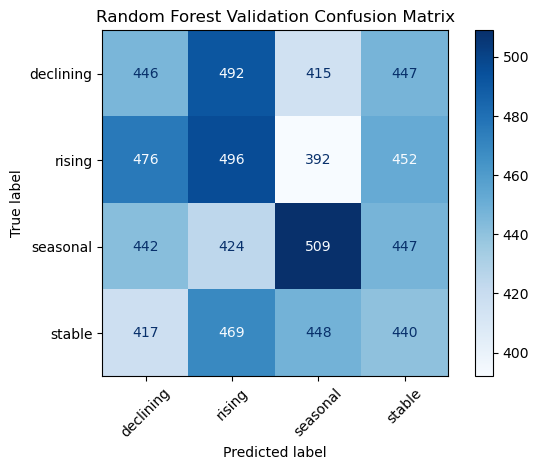

In [5]:
y_val_pred = rf.predict(X_val)

print(classification_report(y_val, y_val_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    xticks_rotation=45,
    cmap="Blues",
)
plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Feature Importance

Random Forest importance is first calculated for each encoded model column, then aggregated back to original feature names. This avoids overstating one-hot encoded variables such as category, country, or traffic source as many separate factors.

In [6]:
encoded_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
})

encoded_importance = encoded_importance.merge(feature_metadata, on="feature", how="left")

factor_importance = (
    encoded_importance.dropna(subset=["original_feature", "feature_group"])
    .groupby(["original_feature", "feature_group"], as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_factors = factor_importance.head(20).copy()

display(top_factors.round(4))

,original_feature,feature_group,importance
0,completion_rate,engagement_observed,0.0332
1,save_rate,engagement_observed,0.0326
2,creator_avg_views,creator,0.0324
3,like_dislike_ratio,engagement_observed,0.0321
4,dislike_rate,engagement_observed,0.0320
5,avg_watch_time_sec,engagement_observed,0.0312
6,comment_ratio,engagement_observed,0.0312
7,share_rate,engagement_observed,0.0311
8,engagement_share_rate,engagement_observed,0.0308
9,saves,engagement_observed,0.0305


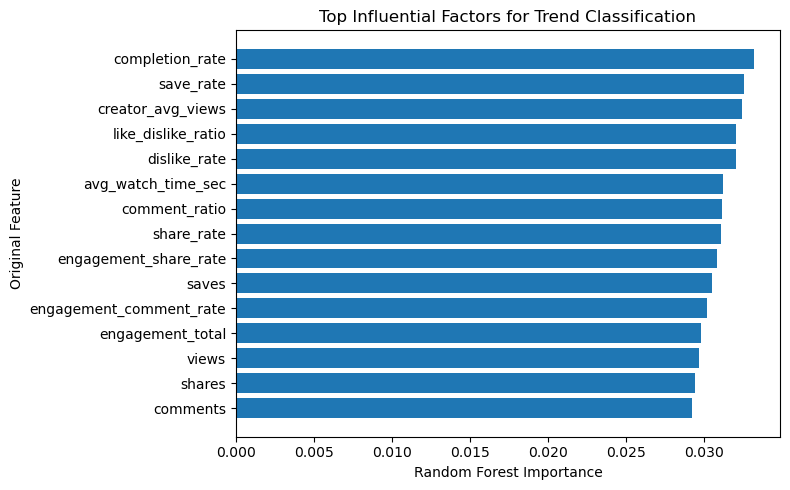

In [7]:
plot_factors = top_factors.head(15).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_factors["original_feature"], plot_factors["importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Original Feature")
plt.title("Top Influential Factors for Trend Classification")
plt.tight_layout()
plt.show()

### Feature Group Importance

The table below sums feature importance by broad feature group. It is useful for comparing engagement, metadata, creator, temporal, and basic content features at a higher level.

In [8]:
group_importance = (
    factor_importance.groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(group_importance.round(4))

,feature_group,importance
0,engagement_observed,0.6048
1,temporal,0.1526
2,metadata,0.1395
3,content_basic,0.0707
4,creator,0.0325


## 5. Sensitivity Check: Remove Synthetic/Caution Features

This section repeats the Random Forest analysis after removing encoded columns whose original feature is marked in `notes.md` as synthetic, synthetic-derived, or cautionary. It uses the existing processed CSVs and `feature_metadata`, so no separate processed file is required.


In [9]:
synthetic_or_caution_features = [
    "dislikes",
    "like_dislike_ratio",
    "dislike_rate",
    "title_length",
    "has_emoji",
    "avg_watch_time_sec",
    "completion_rate",
    "creator_avg_views",
]

synthetic_encoded_features = feature_metadata.loc[
    feature_metadata["original_feature"].isin(synthetic_or_caution_features),
    "feature",
].tolist()

X_train_no_synthetic = X_train.drop(columns=synthetic_encoded_features, errors="ignore")
X_val_no_synthetic = X_val.drop(columns=synthetic_encoded_features, errors="ignore")
X_test_no_synthetic = X_test.drop(columns=synthetic_encoded_features, errors="ignore")

print("Removed encoded columns:", len(synthetic_encoded_features))
print("Original model feature count:", X_train.shape[1])
print("No-synthetic model feature count:", X_train_no_synthetic.shape[1])
display(feature_metadata[feature_metadata["feature"].isin(synthetic_encoded_features)])


Removed encoded columns: 8
Original model feature count: 203
No-synthetic model feature count: 195


,feature,original_feature,feature_group
9,dislikes,dislikes,engagement_observed
13,like_dislike_ratio,like_dislike_ratio,engagement_observed
14,creator_avg_views,creator_avg_views,creator
15,title_length,title_length,content_basic
16,has_emoji,has_emoji,content_basic
17,avg_watch_time_sec,avg_watch_time_sec,engagement_observed
18,completion_rate,completion_rate,engagement_observed
22,dislike_rate,dislike_rate,engagement_observed


In [10]:
baseline_no_synthetic = DummyClassifier(strategy="most_frequent")
baseline_no_synthetic.fit(X_train_no_synthetic, y_train)

rf_no_synthetic = RandomForestClassifier(
    n_estimators=50,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
rf_no_synthetic.fit(X_train_no_synthetic, y_train)

rows = []
for dataset_name, fitted_models, split_data in [
    (
        "original_processed",
        [("majority_baseline", baseline), ("random_forest", rf)],
        [("validation", X_val, y_val), ("test", X_test, y_test)],
    ),
    (
        "no_synthetic_caution",
        [("majority_baseline", baseline_no_synthetic), ("random_forest", rf_no_synthetic)],
        [("validation", X_val_no_synthetic, y_val), ("test", X_test_no_synthetic, y_test)],
    ),
]:
    for model_name, model in fitted_models:
        for split_name, X_part, y_part in split_data:
            y_pred = model.predict(X_part)
            rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "split": split_name,
                "accuracy": accuracy_score(y_part, y_pred),
                "macro_f1": f1_score(y_part, y_pred, average="macro"),
            })

synthetic_comparison_scores = pd.DataFrame(rows)
synthetic_comparison_scores["split"] = pd.Categorical(
    synthetic_comparison_scores["split"],
    categories=["validation", "test"],
    ordered=True,
)
synthetic_comparison_scores = synthetic_comparison_scores.sort_values(
    ["split", "dataset", "macro_f1"],
    ascending=[True, True, False],
).reset_index(drop=True)

display(synthetic_comparison_scores.round(4))


,dataset,model,split,accuracy,macro_f1
0,no_synthetic_caution,random_forest,validation,0.2425,0.2424
1,no_synthetic_caution,majority_baseline,validation,0.2526,0.1008
2,original_processed,random_forest,validation,0.2622,0.2621
3,original_processed,majority_baseline,validation,0.2526,0.1008
4,no_synthetic_caution,random_forest,test,0.2457,0.2457
5,no_synthetic_caution,majority_baseline,test,0.2526,0.1008
6,original_processed,random_forest,test,0.2454,0.2454
7,original_processed,majority_baseline,test,0.2526,0.1008


In [11]:
encoded_importance_no_synthetic = pd.DataFrame({
    "feature": X_train_no_synthetic.columns,
    "importance": rf_no_synthetic.feature_importances_,
})
encoded_importance_no_synthetic = encoded_importance_no_synthetic.merge(
    feature_metadata,
    on="feature",
    how="left",
)

factor_importance_no_synthetic = (
    encoded_importance_no_synthetic.dropna(subset=["original_feature", "feature_group"])
    .groupby(["original_feature", "feature_group"], as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_factors_no_synthetic = factor_importance_no_synthetic.head(20).copy()
display(top_factors_no_synthetic.round(4))

group_importance_no_synthetic = (
    factor_importance_no_synthetic.groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(group_importance_no_synthetic.round(4))


,original_feature,feature_group,importance
0,save_rate,engagement_observed,0.0392
1,saves,engagement_observed,0.0387
2,share_rate,engagement_observed,0.0382
3,comment_ratio,engagement_observed,0.0382
4,engagement_comment_rate,engagement_observed,0.0382
5,engagement_share_rate,engagement_observed,0.0380
6,shares,engagement_observed,0.0377
7,views,engagement_observed,0.0374
8,comments,engagement_observed,0.0373
9,like_rate,engagement_observed,0.0371


,feature_group,importance
0,engagement_observed,0.5609
1,temporal,0.1944
2,metadata,0.1867
3,content_basic,0.0579
4,creator,0.0001


### Sensitivity Check Interpretation

Removing the eight synthetic/caution features reduces the model from 203 to 195 encoded columns. Validation macro F1 drops from about `0.2621` to `0.2424`, but test macro F1 is almost unchanged: `0.2454` for the original processed set versus `0.2457` after removing those features.

The top no-synthetic features are still mostly engagement variables, including `save_rate`, `saves`, `share_rate`, `comment_ratio`, `engagement_comment_rate`, `engagement_share_rate`, `views`, `comments`, and `like_rate`. At the group level, `engagement_observed` remains the largest group, followed by temporal and metadata features.

This means the original RQ1 finding is not heavily dependent on the flagged synthetic/caution columns. Removing them makes the analysis cleaner, but it does not materially improve predictive performance. The cautious interpretation should stay the same: engagement features show the strongest model-based associations, while the overall model remains weak.


## 6. Detailed Summary

The Random Forest does not provide strong predictive performance for `trend_label`. The four classes are nearly balanced, so a simple chance-level expectation is about 25% accuracy. The majority baseline reaches about 25.26% accuracy by always predicting the most frequent class, but its macro F1 is only about 0.1008 because it ignores the other classes.

The Random Forest performs only marginally better on validation, with accuracy around 0.2622 and macro F1 around 0.2621. On the test split, it falls to about 0.2454 accuracy and 0.2454 macro F1, which is slightly below the majority baseline's test accuracy. This suggests that the current feature set and model configuration do not generalize well for trend classification.

The validation classification report shows weak and similar performance across all four classes. `seasonal` has the highest validation F1 score, but it is still only about 0.284. The other classes are close to 0.25 F1. Because precision, recall, macro average, weighted average, and accuracy are all close to each other, the model is not strongly favoring one class, but it is also not separating the classes effectively.

The feature-importance results should therefore be interpreted as exploratory rather than as strong evidence. Within the Random Forest, the most influential factors are mostly engagement-related variables, including `completion_rate`, `save_rate`, `like_dislike_ratio`, `dislike_rate`, `avg_watch_time_sec`, `comment_ratio`, `share_rate`, `saves`, `views`, `shares`, `comments`, and `likes`. Creator-level information such as `creator_avg_views` also appears near the top.

At the feature-group level, `engagement_observed` accounts for the largest share of total Random Forest importance, about 0.6048. It is followed by `temporal` at about 0.1526, `metadata` at about 0.1395, `content_basic` at about 0.0707, and `creator` at about 0.0325. Compared with engagement features, metadata factors such as `category`, `traffic_source`, `region`, `language`, `country`, and especially `platform` have lower individual importance. This suggests that observed engagement behavior is more informative for trend classification than broad platform or region labels in this dataset.

Overall answer to RQ1: the model ranks engagement and creator-performance factors as the strongest influences on trend classification, while platform and geographic metadata appear less influential. However, because model performance is close to chance, these rankings should be reported cautiously as weak model-based associations, not causal drivers or reliable predictors.